# Unity Gaussian Mixture Experiment For Latent Drifting

In [ ]:
import random

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from plotly.subplots import make_subplots
from einops import einsum
from jaxtyping import Float
from pydantic import ConfigDict
from pydantic.dataclasses import dataclass

from src.config.base import ConfigMethodsMixin
from src.data.base import DataConfig
from src.data.dataloading import DataLoaderConfig
from src.data.unity_gaussian_mixture.definition import (
    UnityGaussianMixtureBatch,
    UnityGaussianMixtureDatasetConfig,
    compute_mode_ring_residual,
)
from src.model.mlp import StackedResidualMLP, StackedResidualMLPConfig
from src.model.time_conditioning import TimeConditioningConfig


# Notebook-local runtime controls.
HEADLESS = False
SEED = 0


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
print("seed:", SEED)


In [ ]:
@dataclass(
    kw_only=True,
    config=ConfigDict(
        arbitrary_types_allowed=True,
        extra="forbid",
    ),
)
class ExperimentConfig(ConfigMethodsMixin):
    encoder_config: StackedResidualMLPConfig
    decoder_config: StackedResidualMLPConfig
    encoder_lr: float
    decoder_lr: float
    train_steps: int
    log_every: int
    warmup_steps: int
    t_min: float
    alpha_power: float
    recon_weight: float
    cycle_data_weight: float
    cycle_prior_weight: float
    denoise_weight: float
    score_weight: float
    grad_clip: float

    def __post_init__(self) -> None:
        if not (0.0 < self.t_min < 1.0):
            raise ValueError("t_min must lie in (0, 1)")
        if self.encoder_config.layer_dims[-1] != self.decoder_config.layer_dims[0]:
            raise ValueError("encoder output dim must match decoder input dim")
        if self.decoder_config.layer_dims[-1] != self.encoder_config.layer_dims[0]:
            raise ValueError("decoder output dim must match encoder input dim")


dataset_config = UnityGaussianMixtureDatasetConfig(
    num_modes=5,
    ambient_dim=32,
    mode_std=0.35,
    ring_radius=3.0,
    plane_limit=5.0,
    embed_seed=7,
    train_size=512 * 128,
    val_size=2048,
)

data_config = DataConfig(
    seed=SEED,
    dataset_config=dataset_config,
    trainloader_config=DataLoaderConfig(
        batch_size=512,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        drop_last=True,
    ),
    valloader_config=DataLoaderConfig(
        batch_size=2048,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        drop_last=False,
    ),
)

config = ExperimentConfig(
    encoder_config=StackedResidualMLPConfig.initialize(
        layer_dims=[dataset_config.ambient_dim, 256, 256, 256, dataset_config.ambient_dim],
        time_conditioning_config=TimeConditioningConfig(
            min_t_lambda=0.05,
            max_t_lambda=1.0,
            embedding_dim=256,
        ),
    ),
    decoder_config=StackedResidualMLPConfig.initialize(
        layer_dims=[dataset_config.ambient_dim, 256, 256, dataset_config.ambient_dim],
    ),
    encoder_lr=3e-4,
    decoder_lr=1e-4,
    train_steps=400,
    log_every=20,
    warmup_steps=100,
    t_min=0.05,
    alpha_power=1.0,
    recon_weight=10.0,
    cycle_data_weight=2.0,
    cycle_prior_weight=1.0,
    denoise_weight=1.0,
    score_weight=0.1,
    grad_clip=1.0,
)

data_config, config


(DataConfig(seed=0, dataset_config=UnityGaussianMixtureDatasetConfig(num_modes=5, ambient_dim=32, mode_std=0.35, ring_radius=3.0, plane_limit=5.0, embed_seed=7, train_size=65536, val_size=2048), trainloader_config=DataLoaderConfig(batch_size=512, shuffle=True, num_workers=0, pin_memory=False, drop_last=True), valloader_config=DataLoaderConfig(batch_size=2048, shuffle=False, num_workers=0, pin_memory=False, drop_last=False)),
 ExperimentConfig(encoder_config=StackedResidualMLPConfig(layer_dims=[32, 256, 256, 256, 256, 256, 32], blocks_configs=[ResidualMLPConfig(input_dim=32, hidden_dim=512, output_dim=256, add_embedding=False), ResidualMLPConfig(input_dim=256, hidden_dim=512, output_dim=256, add_embedding=True), ResidualMLPConfig(input_dim=256, hidden_dim=512, output_dim=256, add_embedding=True), ResidualMLPConfig(input_dim=256, hidden_dim=512, output_dim=256, add_embedding=True), ResidualMLPConfig(input_dim=256, hidden_dim=512, output_dim=256, add_embedding=True), ResidualMLPConfig(inp

In [4]:
def project_to_plane(
    points_hd: Float[torch.Tensor, "batch ambient_dim"],
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
) -> Float[torch.Tensor, "batch plane_dim"]:
    return einsum(
        points_hd,
        basis,
        "batch ambient_dim, ambient_dim plane_dim -> batch plane_dim",
    )


def orthogonal_residual(
    points_hd: Float[torch.Tensor, "batch ambient_dim"],
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
) -> Float[torch.Tensor, "batch ambient_dim"]:
    projected = project_to_plane(points_hd, basis)
    lifted = einsum(
        projected,
        basis,
        "batch plane_dim, ambient_dim plane_dim -> batch ambient_dim",
    )
    return points_hd - lifted


def move_batch_to_device(batch: UnityGaussianMixtureBatch, device: torch.device) -> UnityGaussianMixtureBatch:
    return UnityGaussianMixtureBatch(
        x_hd=batch.x_hd.to(device),
        x_2d=batch.x_2d.to(device),
        mode_ids=batch.mode_ids.to(device),
    )


def get_next_batch(
    loader: torch.utils.data.DataLoader,
    loader_iter: iter,
) -> tuple[iter, UnityGaussianMixtureBatch]:
    try:
        batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        batch = next(loader_iter)
    return loader_iter, batch


def draw_noise_levels(batch_size: int, config: ExperimentConfig, device: torch.device) -> torch.Tensor:
    t = torch.rand(batch_size, 1, device=device)
    return config.t_min + (1.0 - config.t_min) * t


def gaussian_posterior_mean(y_t: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    one_minus_t = 1.0 - t
    coef = one_minus_t / (one_minus_t.square() + t.square())
    return coef * y_t


def noise_weight(t: torch.Tensor, power: float) -> torch.Tensor:
    return 1.0 / torch.clamp(t, min=1e-3).pow(power)


def weighted_mse(pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    return ((pred - target).square() * weight).mean()


basis = data_config.dataset_config.get_basis().to(DEVICE)
train_loader = data_config.get_trainloader()
val_loader = data_config.get_valloader()
preview_batch = move_batch_to_device(next(iter(val_loader)), DEVICE)
preview_batch.x_hd.shape, preview_batch.x_2d.shape


(torch.Size([2048, 32]), torch.Size([2048, 2]))

In [5]:
Encoder = StackedResidualMLP
Decoder = StackedResidualMLP


In [ ]:
def freeze_module(module: nn.Module, frozen: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad_(not frozen)


def collect_metrics(
    config: ExperimentConfig,
    data_config: DataConfig,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    encoder: Encoder,
    decoder: Decoder,
    device: torch.device,
) -> dict[str, float]:
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        batch = move_batch_to_device(next(iter(val_loader)), device)
        eval_size = int(batch.x_hd.shape[0])
        x_true = batch.x_hd
        y_true = encoder(x_true, torch.zeros(eval_size, 1, device=device))
        x_recon = decoder(y_true)
        z = torch.randn(eval_size, data_config.dataset_config.ambient_dim, device=device)
        x_gen = decoder(z)
        recon_mse = F.mse_loss(x_recon, x_true).item()
        recon_plane_mse = F.mse_loss(project_to_plane(x_recon, basis), batch.x_2d).item()
        recon_offplane = orthogonal_residual(x_recon, basis).norm(dim=-1).mean().item()
        gen_offplane = orthogonal_residual(x_gen, basis).norm(dim=-1).mean().item()
        gen_radius = project_to_plane(x_gen, basis).norm(dim=-1).mean().item()
    encoder.train()
    decoder.train()
    return {
        "recon_mse": recon_mse,
        "recon_plane_mse": recon_plane_mse,
        "recon_offplane": recon_offplane,
        "gen_offplane": gen_offplane,
        "gen_radius": gen_radius,
    }


def train_experiment(
    config: ExperimentConfig,
    data_config: DataConfig,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    encoder: Encoder,
    decoder: Decoder,
    device: torch.device,
) -> dict[str, list[float]]:
    encoder_optimizer = torch.optim.AdamW(encoder.parameters(), lr=config.encoder_lr)
    decoder_optimizer = torch.optim.AdamW(decoder.parameters(), lr=config.decoder_lr)
    train_loader_iter = iter(train_loader)

    history: dict[str, list[float]] = {
        "step": [],
        "encoder_loss": [],
        "decoder_loss": [],
        "recon_mse": [],
        "recon_plane_mse": [],
        "recon_offplane": [],
        "gen_offplane": [],
        "gen_radius": [],
    }

    for step in range(1, config.train_steps + 1):
        train_loader_iter, batch = get_next_batch(train_loader, train_loader_iter)
        batch = move_batch_to_device(batch, device)
        x_data = batch.x_hd
        zeros = torch.zeros(x_data.shape[0], 1, device=device)

        freeze_module(decoder, frozen=True)
        freeze_module(encoder, frozen=False)
        encoder_optimizer.zero_grad(set_to_none=True)

        y_plain = encoder(x_data, zeros)
        x_recon_for_encoder = decoder(y_plain)
        y_detached = y_plain.detach()
        t = draw_noise_levels(x_data.shape[0], config, device)
        eps = torch.randn_like(y_detached)
        y_t = (1.0 - t) * y_detached + t * eps
        y_denoised = encoder(decoder(y_t), t)
        y_cycle_data = encoder(decoder(y_detached), zeros)
        z = torch.randn(x_data.shape[0], data_config.dataset_config.ambient_dim, device=device)
        z_cycle = encoder(decoder(z), zeros)
        alpha = noise_weight(t, config.alpha_power)

        encoder_loss = (
            config.recon_weight * F.mse_loss(x_recon_for_encoder, x_data)
            + config.cycle_data_weight * F.mse_loss(y_cycle_data, y_detached)
            + config.cycle_prior_weight * F.mse_loss(z_cycle, z)
            + config.denoise_weight * weighted_mse(y_denoised, y_detached, alpha)
        )
        encoder_loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), config.grad_clip)
        encoder_optimizer.step()

        freeze_module(decoder, frozen=False)

        train_loader_iter, batch = get_next_batch(train_loader, train_loader_iter)
        batch = move_batch_to_device(batch, device)
        x_data = batch.x_hd
        zeros = torch.zeros(x_data.shape[0], 1, device=device)

        freeze_module(encoder, frozen=True)
        freeze_module(decoder, frozen=False)
        decoder_optimizer.zero_grad(set_to_none=True)

        with torch.no_grad():
            y_data = encoder(x_data, zeros)
        x_recon = decoder(y_data)
        y_roundtrip = encoder(x_recon, zeros)
        z = torch.randn(x_data.shape[0], data_config.dataset_config.ambient_dim, device=device)
        x_prior = decoder(z)
        z_cycle = encoder(x_prior, zeros)
        t = draw_noise_levels(x_data.shape[0], config, device)
        eps = torch.randn_like(y_roundtrip)
        y_roundtrip_t = (1.0 - t) * y_roundtrip + t * eps
        y_score = encoder(decoder(y_roundtrip_t), t)
        target = gaussian_posterior_mean(y_roundtrip_t.detach(), t)
        alpha = noise_weight(t, config.alpha_power)
        if config.warmup_steps == 0:
            score_scale = 1.0
        else:
            score_scale = min(1.0, max(0.0, (step - config.warmup_steps) / config.warmup_steps))

        decoder_loss = (
            config.recon_weight * F.mse_loss(x_recon, x_data)
            + config.cycle_data_weight * F.mse_loss(y_roundtrip, y_data)
            + config.cycle_prior_weight * F.mse_loss(z_cycle, z)
            + score_scale * config.score_weight * weighted_mse(y_score, target, alpha)
        )
        decoder_loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), config.grad_clip)
        decoder_optimizer.step()

        freeze_module(encoder, frozen=False)

        if step == 1 or step % config.log_every == 0 or step == config.train_steps:
            metrics = collect_metrics(
                config=config,
                data_config=data_config,
                val_loader=val_loader,
                basis=basis,
                encoder=encoder,
                decoder=decoder,
                device=device,
            )
            history["step"].append(step)
            history["encoder_loss"].append(float(encoder_loss.item()))
            history["decoder_loss"].append(float(decoder_loss.item()))
            history["recon_mse"].append(metrics["recon_mse"])
            history["recon_plane_mse"].append(metrics["recon_plane_mse"])
            history["recon_offplane"].append(metrics["recon_offplane"])
            history["gen_offplane"].append(metrics["gen_offplane"])
            history["gen_radius"].append(metrics["gen_radius"])
            print(
                f"step={step:04d} "
                f"enc={encoder_loss.item():.4f} "
                f"dec={decoder_loss.item():.4f} "
                f"recon={metrics['recon_mse']:.4f} "
                f"plane={metrics['recon_plane_mse']:.4f} "
                f"gen_off={metrics['gen_offplane']:.4f}"
            )

    return history


def make_snapshot(
    data_config: DataConfig,
    val_loader: torch.utils.data.DataLoader,
    basis: Float[torch.Tensor, "ambient_dim plane_dim"],
    encoder: Encoder,
    decoder: Decoder,
    device: torch.device,
) -> dict[str, torch.Tensor]:
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        batch = move_batch_to_device(next(iter(val_loader)), device)
        sample_size = int(batch.x_hd.shape[0])
        x_true_hd = batch.x_hd
        x_true_2d = batch.x_2d
        y_true = encoder(x_true_hd, torch.zeros(sample_size, 1, device=device))
        x_recon_hd = decoder(y_true)
        z = torch.randn(sample_size, data_config.dataset_config.ambient_dim, device=device)
        x_gen_hd = decoder(z)
    encoder.train()
    decoder.train()
    return {
        "x_true_2d": x_true_2d.detach().cpu(),
        "x_true_hd": x_true_hd.detach().cpu(),
        "x_recon_2d": project_to_plane(x_recon_hd, basis).detach().cpu(),
        "x_recon_hd": x_recon_hd.detach().cpu(),
        "x_gen_2d": project_to_plane(x_gen_hd, basis).detach().cpu(),
        "x_gen_hd": x_gen_hd.detach().cpu(),
        "recon_offplane": orthogonal_residual(x_recon_hd, basis).norm(dim=-1).detach().cpu(),
        "gen_offplane": orthogonal_residual(x_gen_hd, basis).norm(dim=-1).detach().cpu(),
    }


def show_or_close(fig: plt.Figure) -> None:
    if HEADLESS:
        plt.close(fig)
    else:
        plt.show()


def plot_training_curves(history: dict[str, list[float]]) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history["step"], history["encoder_loss"], label="encoder")
    axes[0].plot(history["step"], history["decoder_loss"], label="decoder")
    axes[0].set_title("Optimization Losses")
    axes[0].set_xlabel("step")
    axes[0].legend()

    axes[1].plot(history["step"], history["recon_mse"], label="ambient recon mse")
    axes[1].plot(history["step"], history["recon_plane_mse"], label="plane recon mse")
    axes[1].set_title("Reconstruction")
    axes[1].set_xlabel("step")
    axes[1].legend()

    axes[2].plot(history["step"], history["recon_offplane"], label="recon off-plane")
    axes[2].plot(history["step"], history["gen_offplane"], label="gen off-plane")
    axes[2].set_title("Orthogonal Residual")
    axes[2].set_xlabel("step")
    axes[2].legend()

    fig.tight_layout()
    show_or_close(fig)


def manifold_score_from_snapshot(
    data_config: DataConfig,
    points_2d: torch.Tensor,
    offplane: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    dataset_config = data_config.dataset_config
    scale = 2.0 * dataset_config.mode_std
    ring_residual = compute_mode_ring_residual(
        points_2d=points_2d.to(dtype=torch.float32),
        mode_centers=dataset_config.get_mode_centers().to(dtype=torch.float32),
        ring_radius=dataset_config.ring_radius,
    )
    score = torch.sqrt(
        (ring_residual / scale) ** 2 + (offplane.to(dtype=torch.float32) / scale) ** 2
    )
    return ring_residual, torch.clamp(score, min=0.0, max=1.0)


def add_mode_ring_shapes(
    figure: go.Figure,
    data_config: DataConfig,
    *,
    row: int,
    col: int,
) -> None:
    subplot_index = (row - 1) * 2 + col
    axis_suffix = '' if subplot_index == 1 else str(subplot_index)
    xref = f'x{axis_suffix}'
    yref = f'y{axis_suffix}'
    dataset_config = data_config.dataset_config
    for center_x, center_y in dataset_config.get_mode_centers().tolist():
        figure.add_shape(
            type='circle',
            xref=xref,
            yref=yref,
            x0=center_x - dataset_config.ring_radius,
            x1=center_x + dataset_config.ring_radius,
            y0=center_y - dataset_config.ring_radius,
            y1=center_y + dataset_config.ring_radius,
            line=dict(color='rgba(45, 111, 142, 0.30)', width=1.5),
        )


def plot_snapshot(data_config: DataConfig, snapshot: dict[str, torch.Tensor]) -> go.Figure:
    plane_limit = data_config.dataset_config.plane_limit
    mode_centers = data_config.dataset_config.get_mode_centers()
    recon_ring_residual, recon_score = manifold_score_from_snapshot(
        data_config=data_config,
        points_2d=snapshot['x_recon_2d'],
        offplane=snapshot['recon_offplane'],
    )
    gen_ring_residual, gen_score = manifold_score_from_snapshot(
        data_config=data_config,
        points_2d=snapshot['x_gen_2d'],
        offplane=snapshot['gen_offplane'],
    )

    figure = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=('Reconstructions', 'Generated Samples'),
        horizontal_spacing=0.08,
    )

    for col, (points_key, score, residual, name) in enumerate(
        [
            ('x_recon_2d', recon_score, recon_ring_residual, 'recon'),
            ('x_gen_2d', gen_score, gen_ring_residual, 'generated'),
        ],
        start=1,
    ):
        add_mode_ring_shapes(figure, data_config, row=1, col=col)
        figure.add_trace(
            go.Scatter(
                x=snapshot['x_true_2d'][:, 0].numpy(),
                y=snapshot['x_true_2d'][:, 1].numpy(),
                mode='markers',
                name='true data',
                showlegend=(col == 1),
                hoverinfo='skip',
                marker=dict(size=4, color='rgba(120, 120, 120, 0.18)'),
            ),
            row=1,
            col=col,
        )
        figure.add_trace(
            go.Scatter(
                x=mode_centers[:, 0].tolist(),
                y=mode_centers[:, 1].tolist(),
                mode='markers',
                name='mode centers',
                showlegend=(col == 1),
                hoverinfo='skip',
                marker=dict(size=9, color='#2D708E', symbol='x'),
            ),
            row=1,
            col=col,
        )
        figure.add_trace(
            go.Scatter(
                x=snapshot[points_key][:, 0].numpy(),
                y=snapshot[points_key][:, 1].numpy(),
                mode='markers',
                name=name,
                showlegend=False,
                customdata=torch.stack([residual, score], dim=-1).numpy(),
                marker=dict(
                    size=6,
                    color=score.numpy(),
                    coloraxis='coloraxis',
                    line=dict(color='rgba(255, 255, 255, 0.18)', width=0.5),
                ),
                hovertemplate=(
                    'x=%{x:.3f}<br>'
                    'y=%{y:.3f}<br>'
                    'ring residual=%{customdata[0]:.3f}<br>'
                    'off-manifold score=%{customdata[1]:.3f}<extra></extra>'
                ),
            ),
            row=1,
            col=col,
        )

    figure.update_layout(
        template='plotly_white',
        title='2D Snapshot',
        coloraxis=dict(
            colorscale='Viridis',
            cmin=0.0,
            cmax=1.0,
            colorbar=dict(
                title='off-manifold',
                tickvals=[0.0, 1.0],
                ticktext=['on', 'off'],
            ),
        ),
        height=560,
        width=1150,
    )
    figure.update_xaxes(range=[-plane_limit, plane_limit], title='x')
    figure.update_yaxes(range=[-plane_limit, plane_limit], title='y', scaleanchor='x', scaleratio=1)
    return figure


def build_models(
    config: ExperimentConfig,
    device: torch.device,
) -> tuple[Encoder, Decoder]:
    encoder = config.encoder_config.get_model().to(device)
    decoder = config.decoder_config.get_model().to(device)
    return encoder, decoder


def run_single_experiment(
    config: ExperimentConfig,
    data_config: DataConfig,
) -> dict[str, object]:
    set_seed(SEED)
    basis = data_config.dataset_config.get_basis().to(DEVICE)
    train_loader = data_config.get_trainloader()
    val_loader = data_config.get_valloader()
    encoder, decoder = build_models(config, DEVICE)
    history = train_experiment(
        config=config,
        data_config=data_config,
        train_loader=train_loader,
        val_loader=val_loader,
        basis=basis,
        encoder=encoder,
        decoder=decoder,
        device=DEVICE,
    )
    snapshot = make_snapshot(
        data_config=data_config,
        val_loader=val_loader,
        basis=basis,
        encoder=encoder,
        decoder=decoder,
        device=DEVICE,
    )
    metrics = collect_metrics(
        config=config,
        data_config=data_config,
        val_loader=val_loader,
        basis=basis,
        encoder=encoder,
        decoder=decoder,
        device=DEVICE,
    )
    return {
        "config": config,
        "data_config": data_config,
        "basis": basis.detach().cpu(),
        "encoder": encoder,
        "decoder": decoder,
        "history": history,
        "snapshot": snapshot,
        "metrics": metrics,
    }


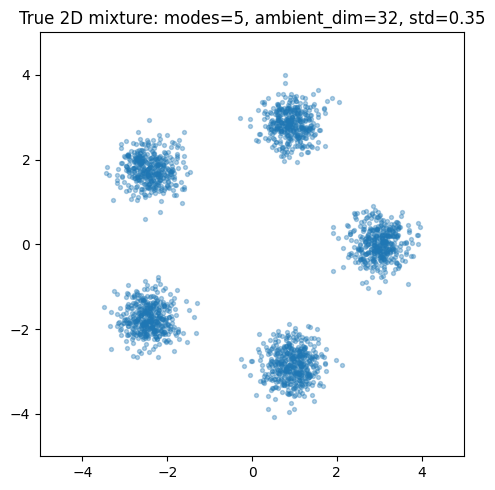

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(preview_batch.x_2d[:, 0].cpu(), preview_batch.x_2d[:, 1].cpu(), s=8, alpha=0.35)
ax.set_xlim(-dataset_config.plane_limit, dataset_config.plane_limit)
ax.set_ylim(-dataset_config.plane_limit, dataset_config.plane_limit)
ax.set_aspect("equal")
ax.set_title(
    f"True 2D mixture: modes={dataset_config.num_modes}, ambient_dim={dataset_config.ambient_dim}, std={dataset_config.mode_std}"
)
fig.tight_layout()
show_or_close(fig)

In [ ]:
results = run_single_experiment(config=config, data_config=data_config)
print(results["metrics"])

step=0001 enc=6.7709 dec=3.6561 recon=0.1327 plane=1.2678 gen_off=2.4370
step=0020 enc=2.6243 dec=1.3079 recon=0.0204 plane=0.1323 gen_off=2.8790
step=0040 enc=1.9813 dec=1.3182 recon=0.0257 plane=0.1800 gen_off=3.6929
step=0060 enc=1.8253 dec=1.4367 recon=0.0165 plane=0.1626 gen_off=4.2666
step=0080 enc=2.3934 dec=1.6572 recon=0.0234 plane=0.1919 gen_off=4.7675
step=0100 enc=2.2457 dec=2.5151 recon=0.0150 plane=0.1261 gen_off=5.0279
step=0120 enc=1.9992 dec=3.9216 recon=0.0464 plane=0.4844 gen_off=5.2623
step=0140 enc=2.4667 dec=2.3320 recon=0.0505 plane=0.4011 gen_off=5.6105
step=0160 enc=2.3661 dec=1.7712 recon=0.0255 plane=0.1419 gen_off=5.9017
step=0180 enc=4.6538 dec=2.6778 recon=0.1047 plane=0.6519 gen_off=6.0542
step=0200 enc=3.9281 dec=2.7976 recon=0.0807 plane=0.7538 gen_off=7.0226
step=0220 enc=2.5290 dec=1.7217 recon=0.0764 plane=0.4277 gen_off=7.1144
step=0240 enc=2.0354 dec=2.1205 recon=0.0341 plane=0.1776 gen_off=7.0720
step=0260 enc=2.8440 dec=2.4402 recon=0.0406 plane=

In [ ]:
plot_training_curves(results["history"])
plot_snapshot(results["data_config"], results["snapshot"])
